- 챕터 4. word2vec 속도 개선
    - 이전 장에서의 CBOW 모델 구현에 몇 가지 문제가 있음, 가장 큰 문제는 말뭉치에 포함된 어휘수가 많아지면 계산량도 커진다는 점, 실제로 어휘 수가 어느 정도를 넘어서면 앞장의 CBOW 모델은 계산 시간이 너무 오래 걸림
    - 이번 장의 목표는 word2vec의 속도 개선, 첫 번째 개선으로는 Embedding 이라는 새로운 계층을 도입, 두 번재 개선으로는 네거티브 샘플링리아는 새로운 손실 함수 도입

- 4.1 word2vec 개선 1
    - 앞장에서는 아래 그림과 같은 CBOW 모델을 구현
    - 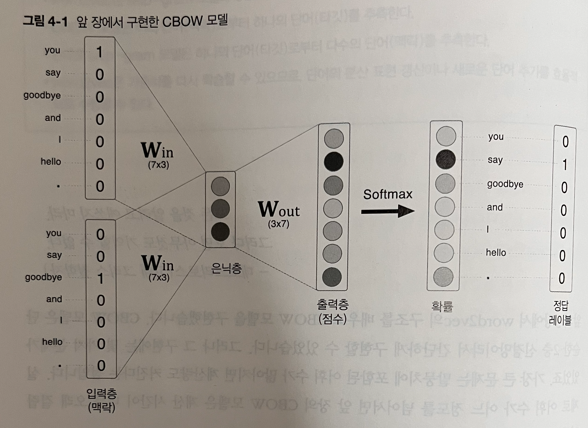
    - 위 그림과 같이 앞 장의 CBOW 모델은 단어 2개를 맥락으로 사용해, 이를 바탕으로 하나의 단어(타겟)를 추측, 이때 입력 측 가중치(W_in)와의 행렬 곱으로 은닉층이 계산되고, 다시 출력 측 가중치(W_out)와의 행렬 곱으로 각 단어의 점수를 구함, 그리고 이 점수에 소프트맥스 함수를 적용해 각 단어의 출현 확률을 얻고, 이 확률을 접답 레이블과 비교하여(정확히는 교차 엔트로피 오차를 적용) 손실을 구함
    - 앞 장에서는 맥락의 윈도우 크기를 1로 한정, 다시 말해 앞뒤 한 단어식만 사용한 것, 이번 장에서는 나중에 어떤 크기의 맥락도 다룰수 있도록 기능을 추가 진행
    - 위 그림의 CBOW 모델도 작은 말뭉치를 다룰때는 문제가 없음, 실제 위 그림에서 다루는 어휘수는 모두 7개인데 이정도는 문제없이 처리 가능, 그러나 거대한 말뭉치를 다루게 되면 몇가지 문제 발생, 그 문제점을 확인하기 위해 어휘가 100만개, 은닉층의 뉴런이 100개인 CBOW 모델을 생각해 보면, word2vec은 아래 그림 처럼 됨
    - 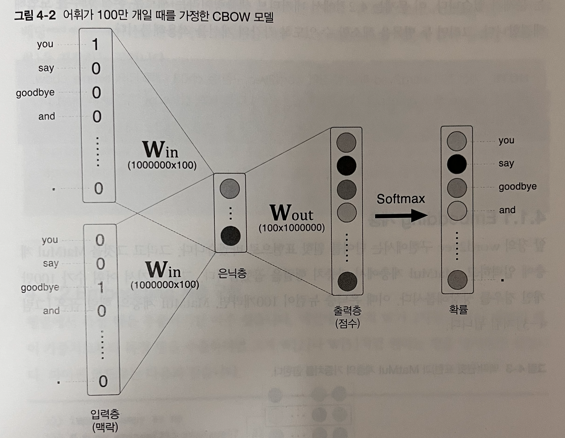
    - 위 그림에서 보듯, 입력층과 출력층에는 각 100만개의 뉴런이 존재, 이 수많은 뉴런 때문에 중간 계산에 많은 시간이 소요, 아래 2가지 계산이 병목이 됨
        - 입력층은 원핫 표현과 가중치 행렬 W_in의 곱 계산
        - 은닉층과 가중치 행렬 W_out의 곱 및 Softmax 계층의 계산
    - 첫번째는 입력층의 원핫 표현과 관련한 문제, 단어를 원핫 표현으로 다루기 때문에 어휘수가 많아지면 원핫 표현의 벡터 크기도 커지는 것, 예컨대 어휘가 100만개 라면 그 원핫 표현 하나만 해도 원소 수가 100만 개인 벡터가 됨, 이는 메모리가 낭비되는 문제 발생, 이 원핫 벡터와 가중치 행렬 W_in을 곱해야 하는 데 이것만으로 계산 자원을 상당히 사용
    - 두번째 문제는 은닉층 이후의 계산, 우선 은닉층과 가중치 행렬 W_out의 곱만 해도 계산량이 상당함, 그리고 Softmax 계층에서도 다루는 어휘가 많아짐에 따라 계산량이 증가하는 문제, 이 문제는 네거티브 샘플링이라는 새로운 손실 함수를 도ㅇ비하야 해결

- 4.1.1. Embedding 계층
    - 앞 장의 word2vec 구현에서는 단어를 원핫 표현으로 변환, 그리고 그것을 MatMul 계층에 입력, MatMul 계층에서 가중치 행렬을 곱함
    - 어휘 수가 100만개가 된다고 할때, 이때 은닉층의 뉴런이 100개라면 MatMul 계층의 행렬 곱은 아래 그림 처럼 됨
    - 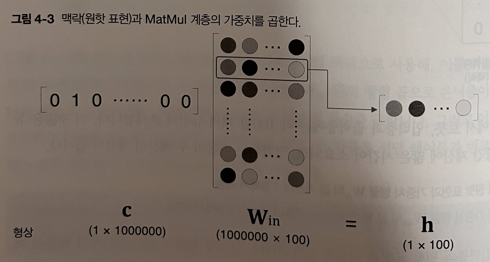
    - 위 그림 처럼 만약 100만개의 어휘를 담은 말뭉치가 있다면, 단어의 원핫 표현도 100만 차원이 됨, 그리고 이런 거대한 벡터와 가중치 행렬을 곱해야 함
    - 위 그림 에서 결과적으로 수행하는 일은 단지 행렬의 특정 행을 추출하는 것뿐, 따라사 원한 표현으로의 변환과 MatMul 계층의 행렬 곱 계산은 필요 없음
    - 그러면 가중치 매개변수로부터 단어ID에 해당하는 행(벡터)을 추출하는 계층을 만들수 있음, 그 계층을 Embedding 계층이라고 지칭, Embedding 계층에 단어 임베딩(분산 표현)을 저장하는 것
    - 자연어 처리 분야에서 단어의 밀집벡터 표현을 단어 임베딩 확은 단어의 분산 표현이라 함

- 4.1.2 Embedding 계층 구현
    - 행렬에서 특정행을 추출하는 것은 가중치 W가 2차원 넘파이 배열일때, 이 가중치로부터 특정 행을 추출하려면 그저 W[2], W[5] 처럼 원하는 행을 명시하면 끝

In [1]:
import numpy as np

W = np.arange(21).reshape(7, 3)
W

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14],
       [15, 16, 17],
       [18, 19, 20]])

In [2]:
W[2]

array([6, 7, 8])

In [3]:
W[5]

array([15, 16, 17])

In [4]:
idx = np.array([1, 0, 3, 0])
W[idx]

array([[ 3,  4,  5],
       [ 0,  1,  2],
       [ 9, 10, 11],
       [ 0,  1,  2]])

- 위 예에서는 인덱스 4개(1, 0, 3, 0번째)를 한 번에 추출, 이처럼 인수에 배열을 사용해도 여러행도 한꺼번에 추출 가능

In [5]:
# Embedding 계층의 forward() 메서드 구현
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out

- 인스턴스 변수 params, grads 사용, 또한 인스턴스 변수 idx에는 추출하는 행의 엔덱스(단어 ID)
- 이어서 역전파(backward)를 새각해 보면, Embedding 계층의 순전파는 가중치 W의 특정행을 흘려보낸 것, 따라서 역전파에서는 앞 층(출력 측 층)으로 부터 전해진 기울기를 다음 층(입력 측 층)으로 그대로 흘려주면 됨, 다만 앞층으로붜 전해진 기울기를 가중치 기울기 dW의 특정 행(idx 번째 행)에 설정, 아래 그림 처럼 됨
- 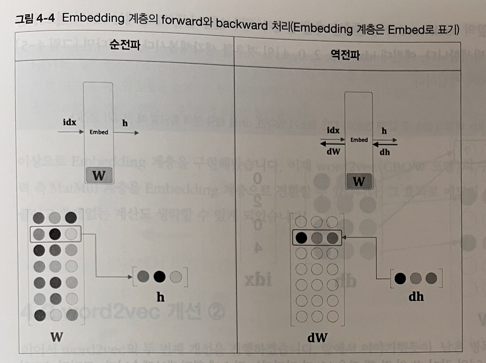
- 위 그림을 기초로 backward()를 구현

In [6]:
# Embedding 계층의 backward() 메서드 구현
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out
    
    def backward(self, dout):
        dW = self.grads
        dW[...] = 0
        dW[self.idx] = dout     # 나쁜 방법, 추후에 수정 되는 지 확인 필요
        return None

- 위 코드는 가중치 기울기 dW를 꺼낸 다음(dW = self.grads), dW[...] = 0 문장에서 dW의 원소를 0으로 덮어씀(dW 자체를 0으로 설정하는 게 아니라, dW의 형상을 유지한 채, 그 원소들을 0으로 덮어씀), 그리고 앞 층에서 전해진 기울기 dout을 idx번째 행에 할당(dW[self.idx] = dout)
- 여기서는 가중치 W와 크기가 같은 행렬 dW를 만들고, dW의 특정 행에 기울기를 할당, 그러나 최종적으로 하고 싶은 일은 가중치 W를 갱신하는 것이므로 일부러 dW와 같은(W 와 같은 크기의) 행랼을 만들 필요는 없음, 이렇게 하지 않고 갱신하려는 행 번호(idx)와 그 기울기(dout)를 따로 저장해두면, 이 정보로부터 가중치(W)의 특정 행만 갱신할 수 있음, 다만 여기에서는 이미 구현해둔 갱신용 클래스(Optimizer)와 조합해 사용하는 것을 고려해 현재와 같이 구현

- 다만 위와 같은 backward() 구현에는 문제가 있음, idx의 원소가 중복될때 문제 발생, 예를 들어 idx가 [0, 2, 0, 4]일 경우 아래 그림과 같은 문제 발생
- 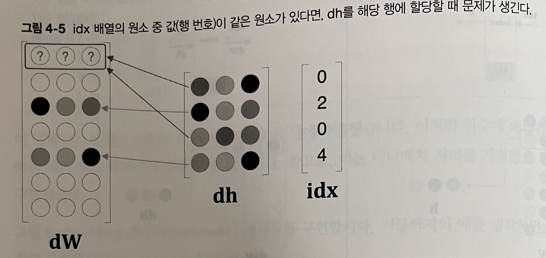
- 위 그림과 같이 dh의 각 행값을 idx가 가리키는 장소에 할당할때, dW의 0번째 행에 2개의 값이 할당되어, 먼저 쓰여진 값을 덮어 쓰게 됨
- 이 중복 문제를 해결하려면 할당이 아닌 더하기를 해야 함, 즉 dh의 각 행을 dW의 해당 행에 더해줌

In [7]:
# Embedding 계층의 backward() 메서드 수정
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out
    
    def backward(self, dout):
        dW = self.grads
        dW[...] = 0
        # 아래 구문 수정
        # dW[self.idx] = dout     # 나쁜 방법, 추후에 수정 되는 지 확인 필요

        # 위 구문을 아래 구문으로 대체
        for i, word_id in enumerate(self.idx):
            dW[word_id] += dout[i]

        # 혹은
        # np.add.at(dW, self.idx, dout)

        return None

- 여기서는 for문을 사용해 해당 인덱스에 기울기를 더함, 이것으로 idx의 중복 인덱스가 있더라고 올바르게 처리
- 참고로 for문대신 넘파이의 np.add.at()을 사용해도 됨, np.add.at(A, idx, B)는 B를 A의 IDX 번째 행에 더해줌
- 일반적으로 파이썬에서 for문보다 넘파이의 내장 메서드를 사용하는 것이 더 빠름, 넘파이의 메서드에서는 속도와 효율을 높여주는 최적화가 적용되어 있음

- 4.2 word2vec 개선
    - word2vec의 두번째 개선 진행, 남은 병목은 은닉층 이후의 처리(행렬 곱과 Softmax 계층의 계산), 네거티브 샘플링(부정적 샘플링)이라는 기법을 사용, Softmax 대신 네거티브 샘플링을 이용하면 어휘가 많아져도 계산량을 낮은 수준에서 일정하게 억게 가능